#  Exploratory Analysis & Visualization (Matplotlib & Seaborn)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

# Load feature table
df = pd.read_csv("../data/processed/fact_sales_features.csv", parse_dates=["Date", "Signup_Date"])


In [ ]:
# Function to prepare matrix for visualization
def prepare_matrix(df):
    # Total revenue by Region
    revenue_by_region = df.groupby("Region")["Calculated_Revenue"].sum().reset_index()

    # Revenue distribution by Category
    revenue_by_category = df.groupby("Category")["Calculated_Revenue"].sum().reset_index()

    # Correlation matrix
    corr_matrix = df[["Quantity","Discount","Calculated_Revenue"]].corr()

    # Monthly sales trends
    monthly_revenue = df.groupby(["Year", "Month_Name"])["Calculated_Revenue"].sum().reset_index()

    # Sort months correctly
    months_order = ["January","February","March","April","May","June",
                "July","August","September","October","November","December"]
    
    monthly_revenue["Month_Name"] = pd.Categorical(
        monthly_revenue["Month_Name"],
        categories=months_order,
        ordered=True
    )

    # Sort by Year and Month_Name
    monthly_revenue = monthly_revenue.sort_values(["Year", "Month_Name"])

    return revenue_by_region, revenue_by_category, corr_matrix, monthly_revenue

# ---  ---
region_matrix, category_matrix, corr_matrix, monthly_matrix = prepare_matrix(df)

# Check one of them
print(region_matrix.head())


    Region  Calculated_Revenue
0     East         379898.6110
1  Midwest         171261.5450
2    North         902170.7430
3    South         217755.0295
4     West         682552.3375


In [ ]:

def plot_interactive_dashboard(df, region_matrix, category_matrix, monthly_revenue, corr_matrix):
    
    # -------- KPIs --------
    total_revenue = df["Calculated_Revenue"].sum()
    total_orders = len(df)
    total_customers = df["CustomerID"].nunique()
    avg_order_value = total_revenue / total_orders
    top_category = category_matrix.sort_values(by="Calculated_Revenue", ascending=False).iloc[0]["Category"]
    top_region = region_matrix.sort_values(by="Calculated_Revenue", ascending=False).iloc[0]["Region"]

    kpis_text = (
        f"Total Revenue: ${total_revenue:,.0f} | "
        f"Total Orders: {total_orders} | "
        f"Customers: {total_customers} | "
        f"AOV: ${avg_order_value:,.0f} | "
        f"Top Category: {top_category} | "
        f"Top Region: {top_region}"
    )
    
    # -------- Create subplot figure --------
    from plotly.subplots import make_subplots
    fig = make_subplots(
        rows=3, cols=2,
        specs=[[{"colspan": 2}, None],
               [{}, {}],
               [{}, {}]],
        subplot_titles=("KPIs","Revenue by Region","Revenue by Category (Boxplot)","Correlation Matrix","Monthly Sales Trend")
    )

    # Add KPI as annotation
    fig.add_trace(go.Scatter(
        x=[0], y=[0],
        mode="text",
        text=[kpis_text],
        textfont=dict(size=14, color="black"),
        showlegend=False
    ), row=1, col=1)

    # -------- Bar Chart: Revenue by Region --------
    bar_region = px.bar(region_matrix, x="Region", y="Calculated_Revenue",
                        color="Calculated_Revenue", color_continuous_scale="Viridis")
    for trace in bar_region.data:
        fig.add_trace(trace, row=2, col=1)

    # -------- Boxplot: Revenue by Category --------
    box_category = px.box(category_matrix, x="Category", y="Calculated_Revenue",
                          color="Category", points="all")
    for trace in box_category.data:
        fig.add_trace(trace, row=2, col=2)

    # -------- Heatmap: Correlation --------
    heatmap_corr = go.Heatmap(
        z=corr_matrix.values,
        x=corr_matrix.columns,
        y=corr_matrix.columns,
        colorscale="RdBu",
        zmin=-1, zmax=1,
        showscale=True
    )
    fig.add_trace(heatmap_corr, row=3, col=1)

    # -------- Time Series: Monthly Revenue --------
    line_ts = px.line(monthly_revenue, x="Month_Name", y="Calculated_Revenue",
                      color="Year", markers=True)
    for trace in line_ts.data:
        fig.add_trace(trace, row=3, col=2)

    # -------- Layout --------
    fig.update_layout(height=900, width=1200, title_text="E-Commerce Interactive Dashboard",
                      showlegend=False)
    fig.update_layout(coloraxis_showscale=False)
    
    
    fig.show()


#plot_interactive_dashboard(df, region_matrix, category_matrix, monthly_matrix, corr_matrix)

C:\Users\EMAN\AppData\Local\Temp\ipykernel_20172\1505219219.py:41: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\EMAN\AppData\Local\Temp\ipykernel_20172\1505219219.py:45: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




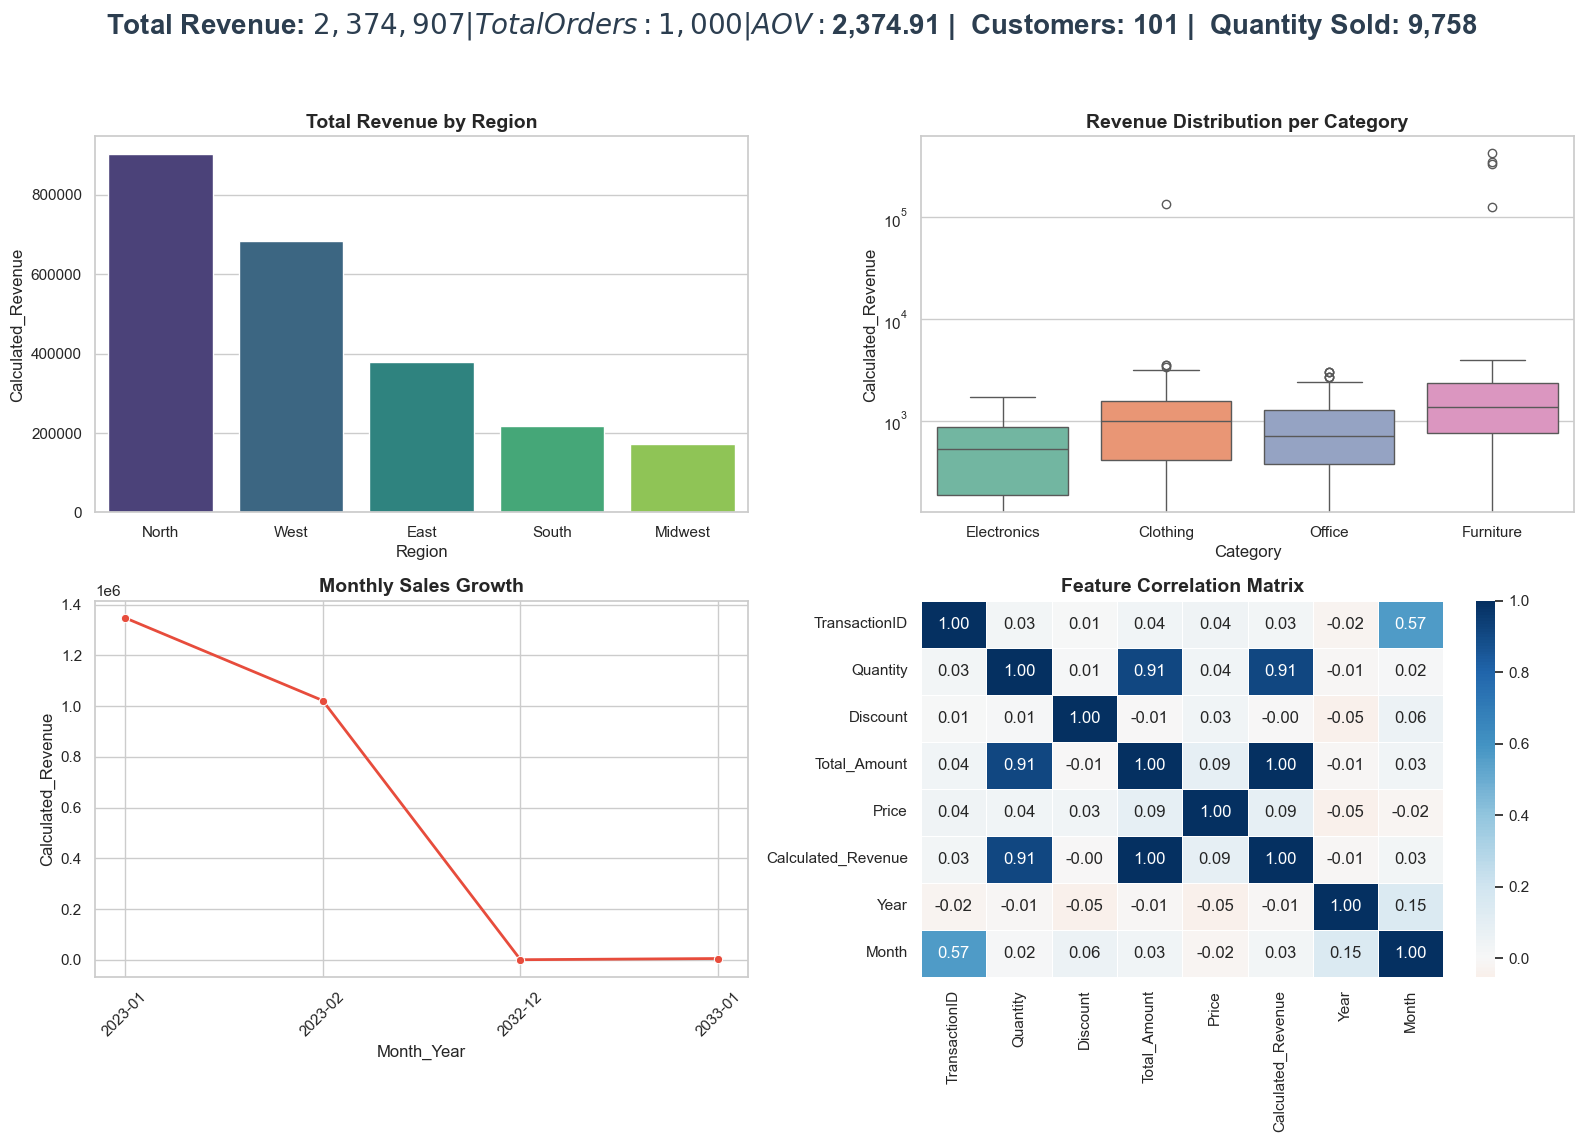

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set visual theme for professional looking plots
sns.set_theme(style="whitegrid")

# 2. Load and prepare data
try:
    # Load dataset with date parsing
    df = pd.read_csv("../data/processed/fact_sales_features.csv", parse_dates=["Date"])
    # Create Year-Month column for time series analysis
    df['Month_Year'] = df['Date'].dt.to_period('M').astype(str)
except Exception as e:
    print(f"Error loading data: {e}")
    exit()

# 3. Calculate Key Performance Indicators (KPIs)
total_revenue = df["Calculated_Revenue"].sum()
total_orders = len(df)
Quantity_sold = df["Quantity"].sum()
avg_order_value = total_revenue / total_orders
unique_customers = df["CustomerID"].nunique()

# 4. Prepare data for the 4 plots
region_data = df.groupby("Region")["Calculated_Revenue"].sum().reset_index().sort_values("Calculated_Revenue", ascending=False)
monthly_trend = df.groupby("Month_Year")["Calculated_Revenue"].sum().reset_index()

# Prepare Correlation Matrix for the Heatmap (Using only numerical columns)
corr_matrix = df.select_dtypes(include=['number']).corr()

# 5. Create Dashboard Layout (2x2 Grid)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

# --- Add KPI Header at the top ---
kpi_text = (f"Total Revenue: ${total_revenue:,.0f}  |  Total Orders: {total_orders:,}  |  "
            f"AOV: ${avg_order_value:,.2f} |  Customers: {unique_customers:,} |  Quantity Sold: {Quantity_sold:,}")
fig.suptitle(kpi_text, fontsize=20, fontweight='bold', color='#2c3e50', y=0.98)

# --- Plot 1: Revenue by Region (Bar Chart) ---
sns.barplot(data=region_data, x="Region", y="Calculated_Revenue", ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("Total Revenue by Region", fontsize=14, fontweight='bold')

# --- Plot 2: Revenue Distribution (Boxplot) ---
sns.boxplot(data=df, x="Category", y="Calculated_Revenue", ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Revenue Distribution per Category", fontsize=14, fontweight='bold')
axes[0, 1].set_yscale('log') 

# --- Plot 3: Monthly Revenue Trend (Line Chart) ---
sns.lineplot(data=monthly_trend, x="Month_Year", y="Calculated_Revenue", ax=axes[1, 0], marker="o", color="#e74c3c", linewidth=2)
axes[1, 0].set_title("Monthly Sales Growth", fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

# --- Plot 4: Feature Correlation (Heatmap) ---
sns.heatmap(corr_matrix, annot=True, cmap="RdBu", center=0, ax=axes[1, 1], fmt=".2f", linewidths=0.5)
axes[1, 1].set_title("Feature Correlation Matrix", fontsize=14, fontweight='bold')

# 6. Final Layout Adjustments
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# 7. Show the final Dashboard
plt.show()
